## Conditional Diffusion - Schema Outputs Notebook

This notebook is a schema-export companion for `ConditionalDiffusionImproved.ipynb`.

It loads a trained checkpoint and exports all visual artifacts needed to build a precise model-process schema:

- `x0` (real image)
- `x_t` (forward noised image)
- true `epsilon` used in forward process
- predicted noise `epsilon_theta(x_t, t, c)`
- one-step reverse output `x_(t-1)`
- reconstructed image `x0_hat`
- full DDIM reverse trajectory snapshots
- composite panel figure + metadata JSON


In [1]:
import os
import copy
import json
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST
from torchvision.utils import make_grid
from einops import rearrange
from torch import einsum

device = "cuda" if torch.cuda.is_available() else "cpu"
MODELS_DIR = "models"
SCHEMA_DIR = "schema_outputs"
os.makedirs(SCHEMA_DIR, exist_ok=True)
print("device:", device)
print("schema output dir:", SCHEMA_DIR)


device: cpu
schema output dir: schema_outputs


In [2]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

transform = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_dataset = FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = FashionMNIST(root="./data", train=False, transform=transform, download=True)
testloader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)


In [3]:
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1.0 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 1e-5, 0.999)


class ImprovedDiffusion:
    def __init__(self, num_timesteps, img_shape, device, min_snr_gamma=5.0, uniform_loss_weights=False):
        self.num_timesteps = num_timesteps
        self.img_shape = img_shape
        self.device = device
        self.min_snr_gamma = min_snr_gamma
        self.uniform_loss_weights = uniform_loss_weights

        betas = cosine_beta_schedule(num_timesteps)
        self.betas = betas.to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        ab = self.alphas_cumprod.clamp(min=1e-9)
        snr = ab / (1.0 - ab)
        self.snr = snr
        if uniform_loss_weights:
            # Min-SNR reweighting down-weights low-noise timesteps; on a small U-Net that can
            # underfit the tail of the denoising trajectory and cause blown-out DDIM samples.
            self.loss_weight = torch.ones(num_timesteps, device=device)
        else:
            clip = torch.full_like(snr, min_snr_gamma)
            self.loss_weight = torch.minimum(snr, clip) / snr.clamp(min=1e-9)

        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod).clamp(min=1e-9)
        )

    def sample_timesteps(self, n):
        return torch.randint(0, self.num_timesteps, (n,), device=self.device, dtype=torch.long)

    def noise_images(self, x0, t):
        ab = self.alphas_cumprod[t][:, None, None, None]
        noise = torch.randn_like(x0)
        xt = ab.sqrt() * x0 + (1.0 - ab).sqrt() * noise
        return xt, noise

    def predict_x0_from_eps(self, x, t, eps):
        ab = self.alphas_cumprod[t][:, None, None, None]
        return (x - (1.0 - ab).sqrt() * eps) / ab.sqrt().clamp(min=1e-8)

    def _predict_eps_cfg(self, model, x, t, labels, guidance_scale, null_label):
        if guidance_scale == 1.0:
            return model(x, t, labels)
        uncond = torch.full_like(labels, null_label)
        eps_c = model(x, t, labels)
        eps_u = model(x, t, uncond)
        return eps_u + guidance_scale * (eps_c - eps_u)

    @torch.no_grad()
    def sample_ddim(self, model, n, labels, steps=100, guidance_scale=2.0, null_label=10, eta=0.0, x_start=None):
        model.eval()
        if x_start is not None:
            x = x_start.to(self.device)
        else:
            x = torch.randn(n, *self.img_shape, device=self.device)
        ts = torch.linspace(0, self.num_timesteps - 1, steps, device=self.device).long()
        ts = torch.unique(ts).sort(descending=True).values
        ts_next = torch.cat([ts[1:], torch.tensor([-1], device=self.device)])

        for t_now, t_next in zip(ts.tolist(), ts_next.tolist()):
            t_b = torch.full((n,), t_now, device=self.device, dtype=torch.long)
            ab = self.alphas_cumprod[t_now]
            ab_next = self.alphas_cumprod[t_next] if t_next >= 0 else torch.ones((), device=self.device)

            eps = self._predict_eps_cfg(model, x, t_b, labels, guidance_scale, null_label)
            pred_x0 = self.predict_x0_from_eps(x, t_b, eps).clamp(-1, 1)

            if t_next < 0:
                x = pred_x0
                break

            sigma = (
                eta
                * (
                    (1.0 - ab_next) / (1.0 - ab).clamp(min=1e-9)
                    * (1.0 - ab / ab_next.clamp(min=1e-9))
                ).sqrt()
            )
            c1 = ab_next.sqrt()
            c2 = ((1.0 - ab_next) - sigma ** 2).clamp(min=0).sqrt()
            noise = torch.randn_like(x) if eta > 0 else 0.0
            x = c1 * pred_x0 + c2 * eps + sigma * noise

        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        return (x * 255).type(torch.uint8)

    @torch.no_grad()
    def sample_ddpm(self, model, n, labels, guidance_scale=1.0, null_label=10):
        model.eval()
        x = torch.randn(n, *self.img_shape, device=self.device)
        for t_now in tqdm(reversed(range(self.num_timesteps)), desc="DDPM", leave=False):
            t_b = torch.full((n,), t_now, device=self.device, dtype=torch.long)
            eps = self._predict_eps_cfg(model, x, t_b, labels, guidance_scale, null_label)
            beta = self.betas[t_b][:, None, None, None]
            ab = self.alphas_cumprod[t_b][:, None, None, None]
            ab_prev = self.alphas_cumprod_prev[t_b][:, None, None, None]
            alpha = self.alphas[t_b][:, None, None, None]

            pred_x0 = self.predict_x0_from_eps(x, t_b, eps).clamp(-1, 1)
            coef1 = beta * ab_prev.sqrt() / (1.0 - ab).clamp(min=1e-8)
            coef2 = (1.0 - ab_prev) * alpha.sqrt() / (1.0 - ab).clamp(min=1e-8)
            mean = coef1 * pred_x0 + coef2 * x

            if t_now > 0:
                noise = torch.randn_like(x)
                var = self.posterior_variance[t_b][:, None, None, None]
                x = (mean + var.sqrt() * noise).clamp(-1, 1)
            else:
                x = mean.clamp(-1, 1)
        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        return (x * 255).type(torch.uint8)


In [4]:
import torch.nn.functional as F

class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x


class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb


class Upsample(nn.Module):
    """Nearest resize + conv avoids ConvTranspose2d checkerboard / vertical striping."""

    def __init__(self, dim):
        super().__init__()
        self.conv = nn.Conv2d(dim, dim, 3, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2.0, mode="nearest")
        return self.conv(x)


def Downsample(dim):
    return nn.Conv2d(dim, dim, 4, 2, 1)


class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))
        self.b = nn.Parameter(torch.zeros(1, dim, 1, 1))

    def forward(self, x):
        var = torch.var(x, dim=1, unbiased=False, keepdim=True)
        mean = torch.mean(x, dim=1, keepdim=True)
        return (x - mean) / (var + self.eps).sqrt() * self.g + self.b


class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = LayerNorm(dim)

    def forward(self, x):
        x = self.norm(x)
        return self.fn(x)


class ConvBlock(nn.Sequential):
    def __init__(self, in_channel, out_channel, kern_size, padd, groups, downsample=True, use_act=True):
        super().__init__()
        self.add_module(
            "conv",
            nn.Conv2d(
                in_channel,
                out_channel,
                kern_size,
                stride=2 if downsample else 1,
                padding=padd,
                groups=groups,
            ),
        )
        self.add_module("norm", nn.GroupNorm(groups, out_channel))
        self.add_module("act", nn.SiLU() if use_act else nn.Identity())


class ResnetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, *, time_emb_dim=None, groups=8, downsample=False):
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_channels))
            if time_emb_dim is not None
            else None
        )

        self.block1 = ConvBlock(in_channels, out_channels, 3, 1, groups, downsample=downsample)
        self.block2 = ConvBlock(out_channels, out_channels, 3, 1, groups, downsample=False, use_act=False)

        if in_channels != out_channels or downsample:
            self.res_conv = nn.Conv2d(
                in_channels, out_channels, kernel_size=1, stride=2 if downsample else 1
            )
        else:
            self.res_conv = nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x, time_emb=None):
        res = self.res_conv(x)

        h = self.block1(x)
        if self.mlp is not None and time_emb is not None:
            time_emb = self.mlp(time_emb)
            h = h + time_emb[:, :, None, None]
        h = self.act(h)
        h = self.block2(h)

        return h + res


class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv)
        sim = einsum("b h d i, b h d j -> b h i j", q, k) * self.scale
        sim = sim - sim.amax(dim=-1, keepdim=True).detach()
        attn = sim.softmax(dim=-1)
        out = einsum("b h i j, b h d j -> b h i d", attn, v)
        out = rearrange(out, "b h (x y) d -> b (h d) x y", x=h, y=w)
        return self.to_out(out)


class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)

        self.to_out = nn.Sequential(nn.Conv2d(hidden_dim, dim, 1), LayerNorm(dim))

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv)

        q = q.softmax(dim=-2)
        k = k.softmax(dim=-1)

        q = q * self.scale
        context = torch.einsum("b h d n, b h e n -> b h d e", k, v)

        out = torch.einsum("b h d e, b h d n -> b h e n", context, q)
        out = rearrange(out, "b h c (x y) -> b (h c) x y", h=self.heads, x=h, y=w)
        return self.to_out(out)


In [5]:
NUM_CLASSES = 10
NULL_LABEL = 10


class Unet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, null_label=NULL_LABEL):
        super().__init__()
        self.null_label = null_label

        time_dim = 32 * 4
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(32),
            nn.Linear(32, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        self.init_conv = nn.Conv2d(1, 32, kernel_size=1)

        self.down1 = ResnetBlock(32, 64, time_emb_dim=time_dim, downsample=True)
        self.attn1 = LinearAttention(64)
        self.down2 = ResnetBlock(64, 128, time_emb_dim=time_dim, downsample=True)
        self.attn2 = LinearAttention(128)
        self.down3 = ResnetBlock(128, 256, time_emb_dim=time_dim, downsample=True)
        self.attn3 = LinearAttention(256)

        self.bottleneck = ResnetBlock(256, 512, time_emb_dim=time_dim, downsample=False)
        self.attn_bottle = Attention(512)

        self.upsample1_op = Upsample(512)
        self.up1 = ResnetBlock(512 + 128, 256, time_emb_dim=time_dim, downsample=False)

        self.upsample2_op = Upsample(256)
        self.up2 = ResnetBlock(256 + 64, 128, time_emb_dim=time_dim, downsample=False)

        self.upsample3_op = Upsample(128)
        self.up3 = ResnetBlock(128 + 32, 64, time_emb_dim=time_dim, downsample=False)

        self.final_res = ResnetBlock(64, 32, time_emb_dim=time_dim, downsample=False)
        self.final_conv = nn.Conv2d(32, 1, 1)

        self.label_emb = nn.Embedding(num_classes + 1, time_dim)

    def forward(self, x, t, y):
        t_emb = self.time_mlp(t.float())
        t_emb = t_emb + self.label_emb(y)

        x_initial_conv_out = self.init_conv(x)
        h = x_initial_conv_out

        # 28x28 path: 28 -> 14 -> 7 -> 4
        h_skip_14x14 = self.down1(h, t_emb)
        h = self.attn1(h_skip_14x14)

        h_skip_7x7 = self.down2(h, t_emb)
        h = self.attn2(h_skip_7x7)

        h_skip_4x4 = self.down3(h, t_emb)
        h = self.attn3(h_skip_4x4)

        h = self.bottleneck(h, t_emb)
        h = self.attn_bottle(h)

        # Keep all skip connections on non-power-of-two image sizes by explicitly
        # matching spatial sizes before concatenation.
        h = self.upsample1_op(h)
        h = F.interpolate(h, size=h_skip_7x7.shape[-2:], mode="nearest")
        h = torch.cat([h, h_skip_7x7], dim=1)
        h = self.up1(h, t_emb)

        h = self.upsample2_op(h)
        h = F.interpolate(h, size=h_skip_14x14.shape[-2:], mode="nearest")
        h = torch.cat([h, h_skip_14x14], dim=1)
        h = self.up2(h, t_emb)

        h = self.upsample3_op(h)
        h = F.interpolate(h, size=x_initial_conv_out.shape[-2:], mode="nearest")
        h = torch.cat([h, x_initial_conv_out], dim=1)
        h = self.up3(h, t_emb)

        h = self.final_res(h, t_emb)
        return self.final_conv(h)


In [6]:
class EMA:
    def __init__(self, model, decay=0.998):
        # Slightly faster than 0.999 so the shadow tracks weights over ~10 Fashion-MNIST epochs.
        self.decay = decay
        self.shadow = copy.deepcopy(model).eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        esd = self.shadow.state_dict()
        for k in esd.keys():
            if esd[k].dtype.is_floating_point:
                esd[k].mul_(self.decay).add_(msd[k].detach(), alpha=1.0 - self.decay)
            else:
                esd[k].copy_(msd[k])


In [8]:
NUM_CLASSES = 10
NULL_LABEL = 10
img_shape = (1, 28, 28)
num_timesteps = 1000

diffusion = ImprovedDiffusion(
    num_timesteps,
    img_shape,
    device,
    min_snr_gamma=5.0,
    uniform_loss_weights=True,
)
model = Unet().to(device)
ema = EMA(model, decay=0.998)

CKPT_PATH = os.path.join(MODELS_DIR, "conditional_diffusion_improved_final.pt")
assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
if "ema_shadow_state_dict" in ckpt:
    ema.shadow.load_state_dict(ckpt["ema_shadow_state_dict"])
model.eval()
ema.shadow.eval()
print("Loaded:", CKPT_PATH)


Loaded: models\conditional_diffusion_improved_final.pt


In [10]:
def to_01(x):
    return ((x.clamp(-1, 1) + 1.0) * 0.5)

def to_np_img(x):
    if x.dim() == 4:
        x = x[0]
    if x.dim() == 3:
        x = x[0]
    return x.detach().cpu().numpy()

def save_gray(path, x01):
    plt.imsave(path, to_np_img(x01), cmap="gray", vmin=0.0, vmax=1.0)

def normalize_vis(x):
    x = x.detach().cpu()
    mn = x.min()
    mx = x.max()
    return (x - mn) / (mx - mn + 1e-8)

def ddpm_step_from_xt(diffusion, model, x_t, t_scalar, labels, guidance_scale=1.0, null_label=10):
    n = x_t.shape[0]
    t_b = torch.full((n,), int(t_scalar), device=x_t.device, dtype=torch.long)
    eps = diffusion._predict_eps_cfg(model, x_t, t_b, labels, guidance_scale, null_label)
    pred_x0 = diffusion.predict_x0_from_eps(x_t, t_b, eps).clamp(-1, 1)
    beta = diffusion.betas[t_b][:, None, None, None]
    ab = diffusion.alphas_cumprod[t_b][:, None, None, None]
    ab_prev = diffusion.alphas_cumprod_prev[t_b][:, None, None, None]
    alpha = diffusion.alphas[t_b][:, None, None, None]
    coef1 = beta * ab_prev.sqrt() / (1.0 - ab).clamp(min=1e-8)
    coef2 = (1.0 - ab_prev) * alpha.sqrt() / (1.0 - ab).clamp(min=1e-8)
    mean = coef1 * pred_x0 + coef2 * x_t
    return mean.clamp(-1, 1), pred_x0, eps

@torch.no_grad()
def ddim_trace(diffusion, model, labels, steps=80, guidance_scale=1.0, null_label=10, x_start=None):
    n = labels.shape[0]
    if x_start is None:
        x = torch.randn(n, *diffusion.img_shape, device=device)
    else:
        x = x_start.clone().to(device)
    ts = torch.linspace(0, diffusion.num_timesteps - 1, steps, device=device).long()
    ts = torch.unique(ts).sort(descending=True).values
    ts_next = torch.cat([ts[1:], torch.tensor([-1], device=device)])
    trace = []
    for t_now, t_next in zip(ts.tolist(), ts_next.tolist()):
        t_b = torch.full((n,), t_now, device=device, dtype=torch.long)
        ab = diffusion.alphas_cumprod[t_now]
        ab_next = diffusion.alphas_cumprod[t_next] if t_next >= 0 else torch.ones((), device=device)
        eps = diffusion._predict_eps_cfg(model, x, t_b, labels, guidance_scale, null_label)
        pred_x0 = diffusion.predict_x0_from_eps(x, t_b, eps).clamp(-1, 1)
        trace.append({"t": int(t_now), "x": x.clone(), "eps": eps.clone(), "x0_hat": pred_x0.clone()})
        if t_next < 0:
            x = pred_x0
            break
        x = ab_next.sqrt() * pred_x0 + (1.0 - ab_next).sqrt() * eps
    return x, trace


In [13]:
torch.manual_seed(42)
np.random.seed(42)

sample_idx = 7
x0_raw, y = test_dataset[sample_idx]
x0 = x0_raw.unsqueeze(0).to(device)
label = torch.tensor([int(y)], device=device, dtype=torch.long)
t_vis = 700
t_tensor = torch.tensor([t_vis], device=device, dtype=torch.long)
x_t, eps_true = diffusion.noise_images(x0, t_tensor)
print("sample idx:", sample_idx, "label:", int(y), class_names[int(y)], "t_vis:", t_vis)


sample idx: 7 label: 6 Shirt t_vis: 700


Will save artifacts:
  x0_real: schema_outputs\x0_real.png
  xt_noised: schema_outputs\xt_t700.png
  eps_true: schema_outputs\eps_true_t700.png
  eps_pred: schema_outputs\eps_pred_t700.png
  x0_hat: schema_outputs\x0_hat_t700.png
  xt_minus_1: schema_outputs\xt_minus_1_t700.png
Saved artifacts.


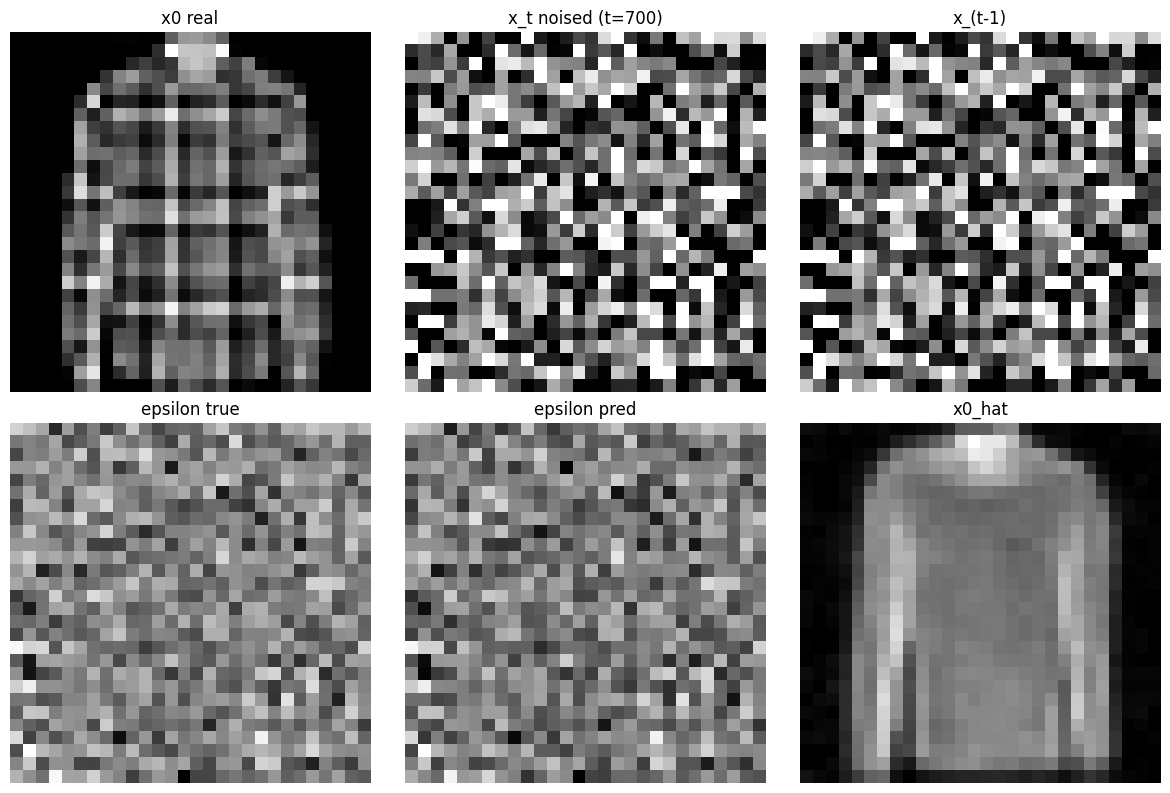

In [14]:
with torch.no_grad():
    x_t_minus_1, x0_hat, eps_pred = ddpm_step_from_xt(
        diffusion, model, x_t, t_vis, label, guidance_scale=1.0, null_label=NULL_LABEL
    )

out = {
    "x0_real": os.path.join(SCHEMA_DIR, "x0_real.png"),
    "xt_noised": os.path.join(SCHEMA_DIR, f"xt_t{t_vis}.png"),
    "eps_true": os.path.join(SCHEMA_DIR, f"eps_true_t{t_vis}.png"),
    "eps_pred": os.path.join(SCHEMA_DIR, f"eps_pred_t{t_vis}.png"),
    "x0_hat": os.path.join(SCHEMA_DIR, f"x0_hat_t{t_vis}.png"),
    "xt_minus_1": os.path.join(SCHEMA_DIR, f"xt_minus_1_t{t_vis}.png"),
}

to_save = {
    "x0_real": to_01(x0),
    "xt_noised": to_01(x_t),
    "x0_hat": to_01(x0_hat),
    "xt_minus_1": to_01(x_t_minus_1),
    "eps_true": normalize_vis(eps_true),
    "eps_pred": normalize_vis(eps_pred),
}

print("Will save artifacts:")
for k, p in out.items():
    print(f"  {k}: {p}")

for k, img in to_save.items():
    save_gray(out[k], img)

print("Saved artifacts.")

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
ax[0,0].imshow(to_np_img(to_01(x0)), cmap="gray"); ax[0,0].set_title("x0 real")
ax[0,1].imshow(to_np_img(to_01(x_t)), cmap="gray"); ax[0,1].set_title(f"x_t noised (t={t_vis})")
ax[0,2].imshow(to_np_img(to_01(x_t_minus_1)), cmap="gray"); ax[0,2].set_title("x_(t-1)")
ax[1,0].imshow(to_np_img(normalize_vis(eps_true)), cmap="gray"); ax[1,0].set_title("epsilon true")
ax[1,1].imshow(to_np_img(normalize_vis(eps_pred)), cmap="gray"); ax[1,1].set_title("epsilon pred")
ax[1,2].imshow(to_np_img(to_01(x0_hat)), cmap="gray"); ax[1,2].set_title("x0_hat")
for a in ax.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()


Will save trajectory frame: schema_outputs\trajectory_frames\t_999.png
Will save trajectory frame: schema_outputs\trajectory_frames\t_859.png
Will save trajectory frame: schema_outputs\trajectory_frames\t_720.png
Will save trajectory frame: schema_outputs\trajectory_frames\t_581.png
Will save trajectory frame: schema_outputs\trajectory_frames\t_429.png
Will save trajectory frame: schema_outputs\trajectory_frames\t_290.png
Will save trajectory frame: schema_outputs\trajectory_frames\t_151.png
Will save trajectory frame: schema_outputs\trajectory_frames\t_0.png
Will save trajectory frame: schema_outputs\trajectory_frames\final_x0.png
Will save reverse panel: schema_outputs\reverse_trajectory_panel.png


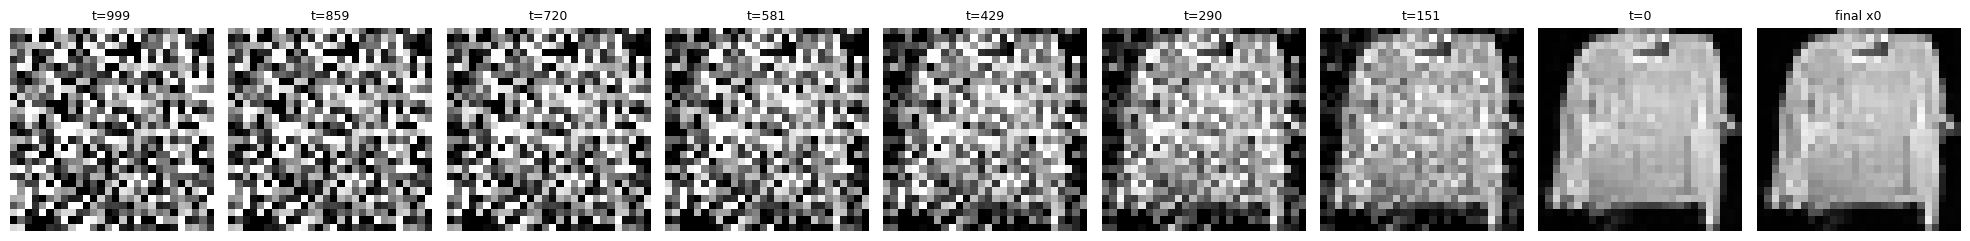

Saved reverse panel: schema_outputs\reverse_trajectory_panel.png


In [15]:
xT = torch.randn(1, *img_shape, device=device)
final_x0, trace = ddim_trace(
    diffusion, model, label, steps=80, guidance_scale=1.0, null_label=NULL_LABEL, x_start=xT
)
idxs = np.linspace(0, len(trace) - 1, 8).astype(int).tolist()
traj_imgs = [to_01(trace[i]["x"]) for i in idxs] + [to_01(final_x0)]
traj_titles = [f"t={trace[i]['t']}" for i in idxs] + ["final x0"]

traj_dir = os.path.join(SCHEMA_DIR, "trajectory_frames")
os.makedirs(traj_dir, exist_ok=True)
for img, ttl in zip(traj_imgs, traj_titles):
    fn = ttl.replace("=", "_").replace(" ", "_") + ".png"
    frame_path = os.path.join(traj_dir, fn)
    print("Will save trajectory frame:", frame_path)
    save_gray(frame_path, img)

panel_path = os.path.join(SCHEMA_DIR, "reverse_trajectory_panel.png")
fig, ax = plt.subplots(1, len(traj_imgs), figsize=(2.2 * len(traj_imgs), 2.7))
for i in range(len(traj_imgs)):
    ax[i].imshow(to_np_img(traj_imgs[i]), cmap="gray")
    ax[i].set_title(traj_titles[i], fontsize=9)
    ax[i].axis("off")
plt.tight_layout()
print("Will save reverse panel:", panel_path)
plt.savefig(panel_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved reverse panel:", panel_path)


Will save composite: schema_outputs\schema_composite_forward_reverse.png


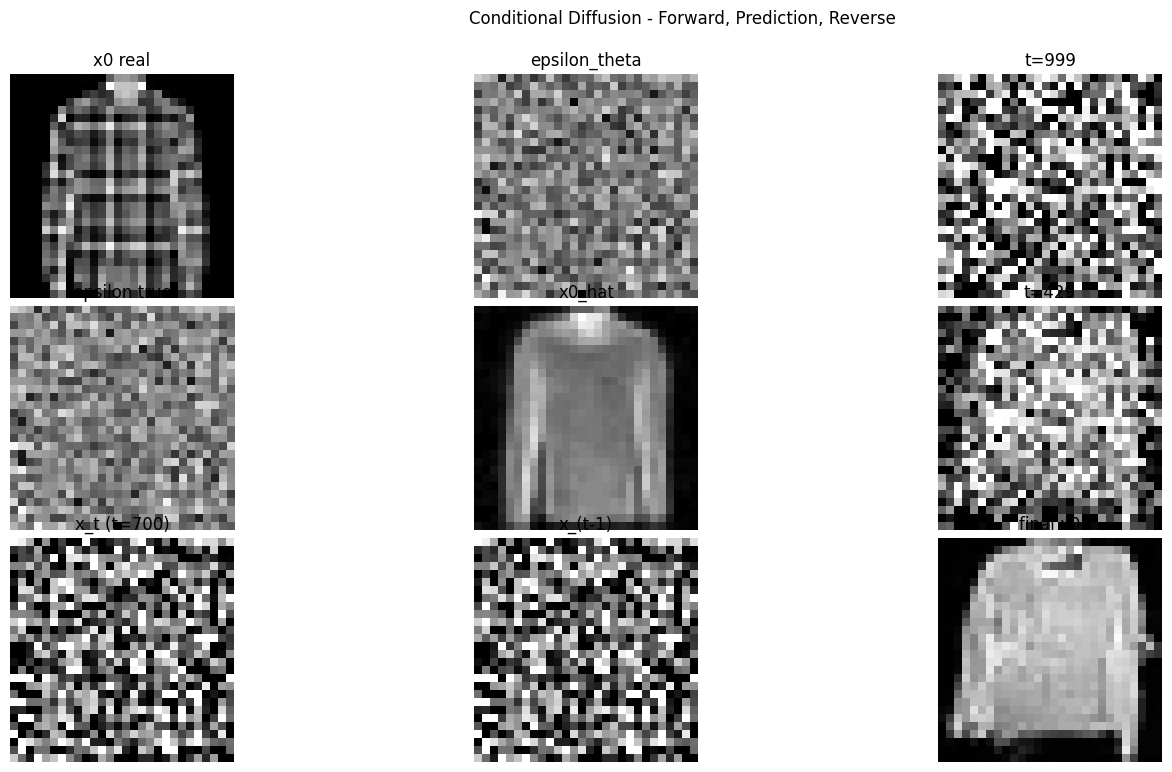

Saved composite: schema_outputs\schema_composite_forward_reverse.png


In [16]:
composite_path = os.path.join(SCHEMA_DIR, "schema_composite_forward_reverse.png")
fig = plt.figure(figsize=(16, 8))
a1 = fig.add_axes([0.05, 0.62, 0.20, 0.28]); a2 = fig.add_axes([0.05, 0.33, 0.20, 0.28]); a3 = fig.add_axes([0.05, 0.04, 0.20, 0.28])
b1 = fig.add_axes([0.34, 0.62, 0.20, 0.28]); b2 = fig.add_axes([0.34, 0.33, 0.20, 0.28]); b3 = fig.add_axes([0.34, 0.04, 0.20, 0.28])
c1 = fig.add_axes([0.63, 0.62, 0.20, 0.28]); c2 = fig.add_axes([0.63, 0.33, 0.20, 0.28]); c3 = fig.add_axes([0.63, 0.04, 0.20, 0.28])

a1.imshow(to_np_img(to_01(x0)), cmap="gray"); a1.set_title("x0 real"); a1.axis("off")
a2.imshow(to_np_img(normalize_vis(eps_true)), cmap="gray"); a2.set_title("epsilon true"); a2.axis("off")
a3.imshow(to_np_img(to_01(x_t)), cmap="gray"); a3.set_title(f"x_t (t={t_vis})"); a3.axis("off")
b1.imshow(to_np_img(normalize_vis(eps_pred)), cmap="gray"); b1.set_title("epsilon_theta"); b1.axis("off")
b2.imshow(to_np_img(to_01(x0_hat)), cmap="gray"); b2.set_title("x0_hat"); b2.axis("off")
b3.imshow(to_np_img(to_01(x_t_minus_1)), cmap="gray"); b3.set_title("x_(t-1)"); b3.axis("off")
c1.imshow(to_np_img(traj_imgs[0]), cmap="gray"); c1.set_title(traj_titles[0]); c1.axis("off")
c2.imshow(to_np_img(traj_imgs[len(traj_imgs)//2]), cmap="gray"); c2.set_title(traj_titles[len(traj_imgs)//2]); c2.axis("off")
c3.imshow(to_np_img(traj_imgs[-1]), cmap="gray"); c3.set_title(traj_titles[-1]); c3.axis("off")
fig.suptitle("Conditional Diffusion - Forward, Prediction, Reverse")
print("Will save composite:", composite_path)
plt.savefig(composite_path, dpi=260, bbox_inches="tight")
plt.show()
print("Saved composite:", composite_path)


In [17]:
meta = {
    "checkpoint_path": CKPT_PATH,
    "image_shape": list(img_shape),
    "sample_idx": int(sample_idx),
    "label_id": int(y),
    "label_name": class_names[int(y)],
    "timestep_visualized": int(t_vis),
    "diffusion_timesteps": int(diffusion.num_timesteps),
    "schedule": "cosine",
    "guidance_scale": 1.0,
    "null_label": int(NULL_LABEL),
    "formulas": {
        "forward": "x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * epsilon",
        "x0_from_eps": "x0_hat = (x_t - sqrt(1-alpha_bar_t) * eps_theta) / sqrt(alpha_bar_t)",
        "cfg": "eps = eps_u + w * (eps_c - eps_u)",
        "ddpm_mean": "mu_t = coef1 * x0_hat + coef2 * x_t",
    },
    "outputs": out,
    "reverse_trajectory_panel": panel_path,
    "composite_schema": composite_path,
}
meta_path = os.path.join(SCHEMA_DIR, "schema_metadata.json")
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)
print("Saved metadata:", meta_path)
print(json.dumps(meta, indent=2))


Saved metadata: schema_outputs\schema_metadata.json
{
  "checkpoint_path": "models\\conditional_diffusion_improved_final.pt",
  "image_shape": [
    1,
    28,
    28
  ],
  "sample_idx": 7,
  "label_id": 6,
  "label_name": "Shirt",
  "timestep_visualized": 700,
  "diffusion_timesteps": 1000,
  "schedule": "cosine",
  "guidance_scale": 1.0,
  "null_label": 10,
  "formulas": {
    "forward": "x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * epsilon",
    "x0_from_eps": "x0_hat = (x_t - sqrt(1-alpha_bar_t) * eps_theta) / sqrt(alpha_bar_t)",
    "cfg": "eps = eps_u + w * (eps_c - eps_u)",
    "ddpm_mean": "mu_t = coef1 * x0_hat + coef2 * x_t"
  },
  "outputs": {
    "x0_real": "schema_outputs\\x0_real.png",
    "xt_noised": "schema_outputs\\xt_t700.png",
    "eps_true": "schema_outputs\\eps_true_t700.png",
    "eps_pred": "schema_outputs\\eps_pred_t700.png",
    "x0_hat": "schema_outputs\\x0_hat_t700.png",
    "xt_minus_1": "schema_outputs\\xt_minus_1_t700.png"
  },
  "reverse_traje